<a href="https://colab.research.google.com/github/Ashu-42/quant_research_crypto_volatility_forecasting/blob/quant_DL_ashu/notebooks/07_Global_MultiAsset_Models_7d.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 07 — Global Multi-Asset Models: BTC, ETH, SOL and XRP

This notebook trains pooled **MLP, GRU and LSTM** models using 7-day sequences from all four assets.

- Each sequence belongs to one asset only.
- Chronological train/validation/test splits are preserved.
- Feature and target scalers are fitted per asset using training data only.
- Asset identity is supplied through one-hot encoding.
- Validation metrics are reported separately for BTC, ETH, SOL and XRP.
- The untouched test set is prepared but not evaluated here.


## 1. Imports and reproducibility


In [1]:
from google.colab import drive
from pathlib import Path
import json, random, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout, GRU, LSTM, Concatenate
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass
print('TensorFlow version:', tf.__version__)


TensorFlow version: 2.20.0


## 2. Paths and configuration


In [2]:
drive.mount('/content/drive')

shared_project_dir = Path('/content/drive/MyDrive/Quant Research')
daily_feature_path = shared_project_dir / 'data' / 'model_ready' / 'crypto_daily_features_v1.parquet'
results_dir = shared_project_dir / 'results' / 'GLOBAL_4_ASSETS' / 'lookback_7d'
models_dir = shared_project_dir / 'models' / 'GLOBAL_4_ASSETS' / 'lookback_7d'
artifacts_dir = shared_project_dir / 'data' / 'model_ready' / 'GLOBAL_4_ASSETS' / 'lookback_7d'
for d in [results_dir, models_dir, artifacts_dir]:
    d.mkdir(parents=True, exist_ok=True)

ASSETS = ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'XRPUSDT']
LOOKBACK_DAYS = 7
FEATURE_COLUMNS = [
    'log_realized_variance', 'daily_return', 'absolute_daily_return',
    'high_low_range', 'log_volume', 'rv_mean_7d', 'rv_mean_30d'
]
TARGET_COLUMN = 'target_log_rv'
print(daily_feature_path)


Mounted at /content/drive
/content/drive/MyDrive/Quant Research/data/model_ready/crypto_daily_features_v1.parquet


## 3. Load and validate daily features


In [3]:
daily_df = pd.read_parquet(daily_feature_path)
daily_df = (daily_df.loc[daily_df['symbol'].isin(ASSETS)]
            .sort_values(['symbol','date']).reset_index(drop=True))
required = {'symbol','date','target_date','target_log_rv','target_rv','split',*FEATURE_COLUMNS}
missing = required - set(daily_df.columns)
if missing:
    raise ValueError(f'Missing columns: {missing}')
print('Daily feature shape:', daily_df.shape)
display(daily_df.groupby('symbol').agg(first_date=('date','min'), last_date=('date','max'), daily_rows=('date','size')))


Daily feature shape: (11502, 21)


,first_date,last_date,daily_rows
symbol,,,
BTCUSDT,2017-08-18 00:00:00+00:00,2026-06-30 00:00:00+00:00,3205
ETHUSDT,2017-08-18 00:00:00+00:00,2026-06-30 00:00:00+00:00,3205
SOLUSDT,2020-08-12 00:00:00+00:00,2026-06-30 00:00:00+00:00,2139
XRPUSDT,2018-05-05 00:00:00+00:00,2026-06-30 00:00:00+00:00,2953


## 4. Create 7-day asset-specific sequences


In [4]:
def create_asset_sequences(asset_df, feature_columns, lookback_days):
    asset_df = asset_df.sort_values('date').reset_index(drop=True)
    X_values, y_values, metadata_rows = [], [], []
    for end_index in range(lookback_days - 1, len(asset_df)):
        start_index = end_index - lookback_days + 1
        window = asset_df.iloc[start_index:end_index + 1]
        final_row = asset_df.iloc[end_index]
        dates = window['date']
        expected = pd.date_range(start=dates.iloc[0], periods=lookback_days, freq='D', tz=dates.iloc[0].tz)
        if not np.array_equal(dates.to_numpy(), expected.to_numpy()):
            continue
        if window[feature_columns].isna().any().any():
            continue
        if pd.isna(final_row[TARGET_COLUMN]):
            continue
        if final_row['target_date'] - final_row['date'] != pd.Timedelta(days=1):
            continue
        if final_row['split'] not in {'train','validation','test'}:
            continue
        X_values.append(window[feature_columns].to_numpy(dtype=np.float32))
        y_values.append(np.float32(final_row[TARGET_COLUMN]))
        metadata_rows.append({
            'symbol': final_row['symbol'],
            'sequence_start_date': dates.iloc[0],
            'sequence_end_date': final_row['date'],
            'target_date': final_row['target_date'],
            'actual_log_rv': final_row['target_log_rv'],
            'actual_rv': final_row['target_rv'],
            'split': final_row['split'],
        })
    return np.asarray(X_values,dtype=np.float32), np.asarray(y_values,dtype=np.float32), pd.DataFrame(metadata_rows)

asset_datasets = {}
for symbol in ASSETS:
    X_asset, y_asset, meta_asset = create_asset_sequences(
        daily_df.loc[daily_df['symbol'].eq(symbol)].copy(), FEATURE_COLUMNS, LOOKBACK_DAYS
    )
    asset_datasets[symbol] = {'X_raw':X_asset,'y_raw':y_asset,'metadata':meta_asset}
    print(symbol, X_asset.shape, meta_asset['split'].value_counts().to_dict())


BTCUSDT (2376, 7, 7) {'train': 1646, 'validation': 365, 'test': 365}
ETHUSDT (2376, 7, 7) {'train': 1646, 'validation': 365, 'test': 365}
SOLUSDT (1838, 7, 7) {'train': 1108, 'validation': 365, 'test': 365}
XRPUSDT (2242, 7, 7) {'train': 1512, 'validation': 365, 'test': 365}


## 5. Per-asset scaling and pooled arrays


In [5]:
asset_to_index = {s:i for i,s in enumerate(ASSETS)}
feature_scalers, target_scalers = {}, {}
pooled = {sp:{'X':[],'A':[],'y_scaled':[],'metadata':[]} for sp in ['train','validation','test']}

for symbol in ASSETS:
    ds = asset_datasets[symbol]
    X_raw, y_raw, meta = ds['X_raw'], ds['y_raw'], ds['metadata']
    train_mask = meta['split'].eq('train').to_numpy()
    if train_mask.sum() == 0:
        raise ValueError(f'No training data for {symbol}')
    nf = X_raw.shape[2]
    fs = StandardScaler().fit(X_raw[train_mask].reshape(-1,nf))
    ts = StandardScaler().fit(y_raw[train_mask].reshape(-1,1))
    feature_scalers[symbol], target_scalers[symbol] = fs, ts
    X_scaled = fs.transform(X_raw.reshape(-1,nf)).reshape(X_raw.shape).astype(np.float32)
    y_scaled = ts.transform(y_raw.reshape(-1,1)).reshape(-1).astype(np.float32)
    A = np.zeros((len(meta),len(ASSETS)),dtype=np.float32)
    A[:,asset_to_index[symbol]] = 1.0
    for sp in pooled:
        m = meta['split'].eq(sp).to_numpy()
        pooled[sp]['X'].append(X_scaled[m]); pooled[sp]['A'].append(A[m]); pooled[sp]['y_scaled'].append(y_scaled[m]); pooled[sp]['metadata'].append(meta.loc[m].copy())

for sp in pooled:
    pooled[sp]['X'] = np.concatenate(pooled[sp]['X'])
    pooled[sp]['A'] = np.concatenate(pooled[sp]['A'])
    pooled[sp]['y_scaled'] = np.concatenate(pooled[sp]['y_scaled'])
    pooled[sp]['metadata'] = pd.concat(pooled[sp]['metadata'],ignore_index=True)

X_train,A_train,y_train_scaled = pooled['train']['X'], pooled['train']['A'], pooled['train']['y_scaled']
X_val,A_val,y_val_scaled = pooled['validation']['X'], pooled['validation']['A'], pooled['validation']['y_scaled']
X_test,A_test,y_test_scaled = pooled['test']['X'], pooled['test']['A'], pooled['test']['y_scaled']
validation_metadata = pooled['validation']['metadata'].reset_index(drop=True)
test_metadata = pooled['test']['metadata'].reset_index(drop=True)
print('Train:',X_train.shape,A_train.shape,y_train_scaled.shape)
print('Validation:',X_val.shape)
print('Test:',X_test.shape)
display(validation_metadata['symbol'].value_counts())


Train: (5912, 7, 7) (5912, 4) (5912,)
Validation: (1460, 7, 7)
Test: (1460, 7, 7)


,count
symbol,
BTCUSDT,365
ETHUSDT,365
SOLUSDT,365
XRPUSDT,365


## 6. Save pooled artifacts


In [6]:
for name, arr in {
    'X_train_scaled.npy':X_train,'X_val_scaled.npy':X_val,'X_test_scaled.npy':X_test,
    'asset_train_one_hot.npy':A_train,'asset_val_one_hot.npy':A_val,'asset_test_one_hot.npy':A_test,
    'y_train_scaled.npy':y_train_scaled,'y_val_scaled.npy':y_val_scaled,'y_test_scaled.npy':y_test_scaled,
}.items():
    np.save(artifacts_dir/name, arr)
validation_metadata.to_parquet(artifacts_dir/'validation_metadata.parquet',index=False)
test_metadata.to_parquet(artifacts_dir/'test_metadata.parquet',index=False)
joblib.dump(feature_scalers, artifacts_dir/'feature_scalers_by_asset.joblib')
joblib.dump(target_scalers, artifacts_dir/'target_scalers_by_asset.joblib')
with open(artifacts_dir/'experiment_configuration.json','w') as f:
    json.dump({'assets':ASSETS,'lookback_days':LOOKBACK_DAYS,'feature_columns':FEATURE_COLUMNS,
               'target':TARGET_COLUMN,'train_shape':list(X_train.shape),
               'validation_shape':list(X_val.shape),'test_shape':list(X_test.shape)},f,indent=2)
print('Artifacts saved.')


Artifacts saved.


## 7. Metrics and inverse transformation helpers


In [7]:
def mae(y_true,y_pred): return np.mean(np.abs(np.asarray(y_true)-np.asarray(y_pred)))
def rmse(y_true,y_pred): return np.sqrt(np.mean((np.asarray(y_true)-np.asarray(y_pred))**2))
def qlike(y_true,y_pred,epsilon=1e-12):
    yt=np.maximum(np.asarray(y_true),epsilon); yp=np.maximum(np.asarray(y_pred),epsilon)
    r=yt/yp
    return np.mean(r-np.log(r)-1)

def inverse_target_predictions(pred_scaled, metadata):
    pred_log=np.empty(len(pred_scaled),dtype=float)
    for symbol in ASSETS:
        m=metadata['symbol'].eq(symbol).to_numpy()
        pred_log[m]=target_scalers[symbol].inverse_transform(pred_scaled[m].reshape(-1,1)).reshape(-1)
    return pred_log, np.exp(pred_log)

def evaluate_by_asset(model_name,pred_rv,metadata):
    rows=[]
    for symbol in ASSETS:
        m=metadata['symbol'].eq(symbol).to_numpy()
        yt=metadata.loc[m,'actual_rv'].to_numpy(); yp=pred_rv[m]
        rows.append({'asset':symbol,'model':model_name,'n_observations':int(m.sum()),'mae':mae(yt,yp),'rmse':rmse(yt,yp),'qlike':qlike(yt,yp)})
    yt=metadata['actual_rv'].to_numpy()
    rows.append({'asset':'ALL_ASSETS','model':model_name,'n_observations':len(metadata),'mae':mae(yt,pred_rv),'rmse':rmse(yt,pred_rv),'qlike':qlike(yt,pred_rv)})
    return pd.DataFrame(rows)


## 8. Per-asset baselines


In [8]:
LOG_RV_INDEX=FEATURE_COLUMNS.index('log_realized_variance')
RV7_INDEX=FEATURE_COLUMNS.index('rv_mean_7d')
RV30_INDEX=FEATURE_COLUMNS.index('rv_mean_30d')
baseline_rows=[]
for symbol in ASSETS:
    ds=asset_datasets[symbol]; meta=ds['metadata']; m=meta['split'].eq('validation').to_numpy()
    Xr=ds['X_raw'][m]; mv=meta.loc[m].reset_index(drop=True); yt=mv['actual_rv'].to_numpy()
    preds={
        'Persistence':np.exp(Xr[:,-1,LOG_RV_INDEX]),
        '7-Day Mean RV':Xr[:,-1,RV7_INDEX],
        '30-Day Mean RV':Xr[:,-1,RV30_INDEX],
    }
    for name,yp in preds.items():
        baseline_rows.append({'asset':symbol,'model':name,'n_observations':len(yt),'mae':mae(yt,yp),'rmse':rmse(yt,yp),'qlike':qlike(yt,yp)})
baseline_metrics_df=pd.DataFrame(baseline_rows)
display(baseline_metrics_df.sort_values(['asset','qlike']))


,asset,model,n_observations,mae,rmse,qlike
1,BTCUSDT,7-Day Mean RV,365,0.000455,0.000899,0.343857
2,BTCUSDT,30-Day Mean RV,365,0.000483,0.000921,0.399752
0,BTCUSDT,Persistence,365,0.000514,0.001087,0.464700
4,ETHUSDT,7-Day Mean RV,365,0.000964,0.001987,0.368690
5,ETHUSDT,30-Day Mean RV,365,0.000977,0.001963,0.407022
3,ETHUSDT,Persistence,365,0.001017,0.002290,0.415368
7,SOLUSDT,7-Day Mean RV,365,0.001441,0.002961,0.276899
6,SOLUSDT,Persistence,365,0.001480,0.003177,0.325781
8,SOLUSDT,30-Day Mean RV,365,0.001557,0.002989,0.342676
10,XRPUSDT,7-Day Mean RV,365,0.002212,0.004302,0.469705


## 9. Model builders


In [10]:
def compile_model(seq_input,asset_input,x,name):
    x=Concatenate()([x,asset_input]); x=Dense(16,activation='relu')(x); out=Dense(1)(x)
    model=Model([seq_input,asset_input],out,name=name)
    model.compile(optimizer=tf.keras.optimizers.Adam(0.001),loss='mse',metrics=[tf.keras.metrics.MeanAbsoluteError(name='mae')])
    return model

def build_global_mlp(lb,nf,na):
    si=Input((lb,nf),name='sequence_input'); ai=Input((na,),name='asset_input')
    x=Flatten()(si); x=Dense(64,activation='relu')(x); x=Dropout(0.20)(x); x=Dense(32,activation='relu')(x)
    return compile_model(si,ai,x,'global_mlp')

def build_global_gru(lb,nf,na):
    si=Input((lb,nf),name='sequence_input'); ai=Input((na,),name='asset_input')
    x=GRU(32,dropout=0.0,recurrent_dropout=0.0)(si); x=Dropout(0.20)(x); x=Dense(16,activation='relu')(x)
    return compile_model(si,ai,x,'global_gru')

def build_global_lstm(lb,nf,na):
    si=Input((lb,nf),name='sequence_input'); ai=Input((na,),name='asset_input')
    x=LSTM(32,dropout=0.0,recurrent_dropout=0.0)(si); x=Dropout(0.20)(x); x=Dense(16,activation='relu')(x)
    return compile_model(si,ai,x,'global_lstm')


## 10. Train MLP, GRU and LSTM


In [11]:
MODEL_BUILDERS={'MLP':build_global_mlp,'GRU':build_global_gru,'LSTM':build_global_lstm}
metric_frames=[]; prediction_frames=[]; histories={}
for model_name,builder in MODEL_BUILDERS.items():
    print(''+'='*70+'Training '+model_name+''+'='*70)
    tf.keras.backend.clear_session(); random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
    model=builder(X_train.shape[1],X_train.shape[2],A_train.shape[1])
    model_dir=models_dir/model_name; model_dir.mkdir(parents=True,exist_ok=True)
    callbacks=[
        EarlyStopping(monitor='val_loss',patience=15,restore_best_weights=True,min_delta=1e-4,verbose=1),
        ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=5,min_lr=1e-6,verbose=1),
        ModelCheckpoint(model_dir/f'best_global_{model_name.lower()}.keras',monitor='val_loss',save_best_only=True,verbose=1),
    ]
    history=model.fit([X_train,A_train],y_train_scaled,validation_data=([X_val,A_val],y_val_scaled),epochs=200,batch_size=32,shuffle=False,callbacks=callbacks,verbose=1)
    pred_scaled=model.predict([X_val,A_val],batch_size=32,verbose=0).reshape(-1)
    pred_log,pred_rv=inverse_target_predictions(pred_scaled,validation_metadata)
    metrics=evaluate_by_asset(f'Global-{model_name}-7d',pred_rv,validation_metadata)
    metric_frames.append(metrics)
    pred_df=validation_metadata.copy(); pred_df['model']=f'Global-{model_name}-7d'; pred_df['pred_log_rv']=pred_log; pred_df['pred_rv']=pred_rv
    prediction_frames.append(pred_df)
    hist_df=pd.DataFrame(history.history); hist_df['epoch']=np.arange(len(hist_df))+1; histories[model_name]=hist_df
    out_dir=results_dir/model_name; out_dir.mkdir(parents=True,exist_ok=True)
    hist_df.to_csv(out_dir/'training_history.csv',index=False)
    metrics.to_csv(out_dir/'validation_metrics_by_asset.csv',index=False)
    pred_df.to_parquet(out_dir/'validation_predictions.parquet',index=False)
    model.save(model_dir/f'final_global_{model_name.lower()}.keras')
    display(metrics.sort_values('qlike'))


======================================================================Training MLP======================================================================
Epoch 1/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8747 - mae: 0.7130
Epoch 1: val_loss improved from None to 0.49180, saving model to /content/drive/MyDrive/Quant Research/models/GLOBAL_4_ASSETS/lookback_7d/MLP/best_global_mlp.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Quant Research/models/GLOBAL_4_ASSETS/lookback_7d/MLP/best_global_mlp.keras
185/185 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6802 - mae: 0.6298 - val_loss: 0.4918 - val_mae: 0.5468 - learning_rate: 0.0010
Epoch 2/200
167/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5259 - mae: 0.5513
Epoch 2: val_loss improved from 0.49180 to 0.45320, saving model to /content/drive/MyDrive/Quant Research/models/GLOBAL_4_ASSETS/lookback_7d/MLP/best_global_mlp.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Quant Research/models/GLOBAL_

,asset,model,n_observations,mae,rmse,qlike
2,SOLUSDT,Global-MLP-7d,365,0.001127,0.002528,0.199853
1,ETHUSDT,Global-MLP-7d,365,0.000758,0.001739,0.244669
0,BTCUSDT,Global-MLP-7d,365,0.000373,0.000812,0.247444
4,ALL_ASSETS,Global-MLP-7d,1460,0.000978,0.002518,0.272339
3,XRPUSDT,Global-MLP-7d,365,0.001655,0.003911,0.397392


======================================================================Training GRU======================================================================
Epoch 1/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7680 - mae: 0.6738
Epoch 1: val_loss improved from None to 0.48538, saving model to /content/drive/MyDrive/Quant Research/models/GLOBAL_4_ASSETS/lookback_7d/GRU/best_global_gru.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Quant Research/models/GLOBAL_4_ASSETS/lookback_7d/GRU/best_global_gru.keras
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.6688 - mae: 0.6210 - val_loss: 0.4854 - val_mae: 0.5455 - learning_rate: 0.0010
Epoch 2/200
178/185 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5419 - mae: 0.5574
Epoch 2: val_loss improved from 0.48538 to 0.48318, saving model to /content/drive/MyDrive/Quant Research/models/GLOBAL_4_ASSETS/lookback_7d/GRU/best_global_gru.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Quant Research/models/GLOBAL_

,asset,model,n_observations,mae,rmse,qlike
2,SOLUSDT,Global-GRU-7d,365,0.001115,0.002443,0.193730
0,BTCUSDT,Global-GRU-7d,365,0.000361,0.000808,0.265197
1,ETHUSDT,Global-GRU-7d,365,0.000749,0.001753,0.272646
4,ALL_ASSETS,Global-GRU-7d,1460,0.000957,0.002441,0.282636
3,XRPUSDT,Global-GRU-7d,365,0.001601,0.003760,0.398971


======================================================================Training LSTM======================================================================
Epoch 1/200
181/185 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7537 - mae: 0.6730
Epoch 1: val_loss improved from None to 0.49476, saving model to /content/drive/MyDrive/Quant Research/models/GLOBAL_4_ASSETS/lookback_7d/LSTM/best_global_lstm.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Quant Research/models/GLOBAL_4_ASSETS/lookback_7d/LSTM/best_global_lstm.keras
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.6784 - mae: 0.6292 - val_loss: 0.4948 - val_mae: 0.5485 - learning_rate: 0.0010
Epoch 2/200
180/185 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5456 - mae: 0.5585
Epoch 2: val_loss did not improve from 0.49476
185/185 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.5467 - mae: 0.5572 - val_loss: 0.4964 - val_mae: 0.5549 - learning_rate: 0.0010
Epoch 3/200
176/185 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5120 -

,asset,model,n_observations,mae,rmse,qlike
2,SOLUSDT,Global-LSTM-7d,365,0.001177,0.002570,0.192756
1,ETHUSDT,Global-LSTM-7d,365,0.000754,0.001746,0.256810
0,BTCUSDT,Global-LSTM-7d,365,0.000363,0.000822,0.270049
4,ALL_ASSETS,Global-LSTM-7d,1460,0.000982,0.002512,0.287813
3,XRPUSDT,Global-LSTM-7d,365,0.001635,0.003862,0.431636


## 11. Final validation comparison by asset


In [12]:
deep_metrics_df=pd.concat(metric_frames,ignore_index=True)
final_comparison_df=pd.concat([baseline_metrics_df,deep_metrics_df],ignore_index=True)
final_comparison_df=(final_comparison_df.sort_values(['asset','qlike','mae','rmse']).reset_index(drop=True))
final_comparison_df['qlike_rank_within_asset']=(final_comparison_df.groupby('asset')['qlike'].rank(method='min').astype(int))
final_comparison_df=final_comparison_df[['asset','qlike_rank_within_asset','model','n_observations','mae','rmse','qlike']]
final_comparison_df.to_csv(results_dir/'final_validation_comparison_by_asset.csv',index=False)
display(final_comparison_df.style.format({'mae':'{:.8f}','rmse':'{:.8f}','qlike':'{:.6f}'}))


,asset,qlike_rank_within_asset,model,n_observations,mae,rmse,qlike
0,ALL_ASSETS,1,Global-MLP-7d,1460,0.00097828,0.00251826,0.272339
1,ALL_ASSETS,2,Global-GRU-7d,1460,0.00095687,0.00244102,0.282636
2,ALL_ASSETS,3,Global-LSTM-7d,1460,0.00098232,0.00251217,0.287813
3,BTCUSDT,1,Global-MLP-7d,365,0.00037331,0.00081176,0.247444
4,BTCUSDT,2,Global-GRU-7d,365,0.00036146,0.00080757,0.265197
5,BTCUSDT,3,Global-LSTM-7d,365,0.00036349,0.00082216,0.270049
6,BTCUSDT,4,7-Day Mean RV,365,0.00045483,0.00089898,0.343857
7,BTCUSDT,5,30-Day Mean RV,365,0.00048324,0.00092118,0.399752
8,BTCUSDT,6,Persistence,365,0.00051363,0.00108687,0.464700
9,ETHUSDT,1,Global-MLP-7d,365,0.00075761,0.00173944,0.244669


## 12. Best validation model for each asset


In [13]:
best_model_by_asset_df=(final_comparison_df.sort_values(['asset','qlike','mae','rmse']).groupby('asset',as_index=False).first())
best_model_by_asset_df.to_csv(results_dir/'best_validation_model_by_asset.csv',index=False)
display(best_model_by_asset_df.style.format({'mae':'{:.8f}','rmse':'{:.8f}','qlike':'{:.6f}'}))


,asset,qlike_rank_within_asset,model,n_observations,mae,rmse,qlike
0,ALL_ASSETS,1,Global-MLP-7d,1460,0.00097828,0.00251826,0.272339
1,BTCUSDT,1,Global-MLP-7d,365,0.00037331,0.00081176,0.247444
2,ETHUSDT,1,Global-MLP-7d,365,0.00075761,0.00173944,0.244669
3,SOLUSDT,1,Global-LSTM-7d,365,0.00117654,0.00256971,0.192756
4,XRPUSDT,1,Global-MLP-7d,365,0.00165550,0.00391053,0.397392


## 13. QLIKE pivot table


In [14]:
qlike_pivot_df=final_comparison_df.pivot(index='model',columns='asset',values='qlike')
qlike_pivot_df.to_csv(results_dir/'qlike_pivot_by_asset.csv')
display(qlike_pivot_df.style.format('{:.6f}'))


asset,ALL_ASSETS,BTCUSDT,ETHUSDT,SOLUSDT,XRPUSDT
model,,,,,
30-Day Mean RV,nan,0.399752,0.407022,0.342676,0.625613
7-Day Mean RV,nan,0.343857,0.368690,0.276899,0.469705
Global-GRU-7d,0.282636,0.265197,0.272646,0.193730,0.398971
Global-LSTM-7d,0.287813,0.270049,0.256810,0.192756,0.431636
Global-MLP-7d,0.272339,0.247444,0.244669,0.199853,0.397392
Persistence,nan,0.464700,0.415368,0.325781,0.554703


## 14. Validation plots


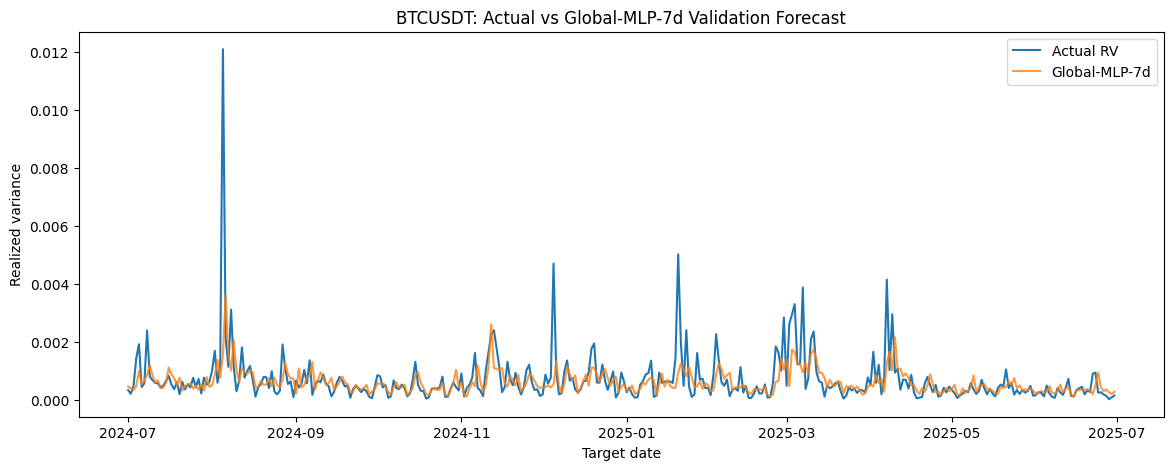

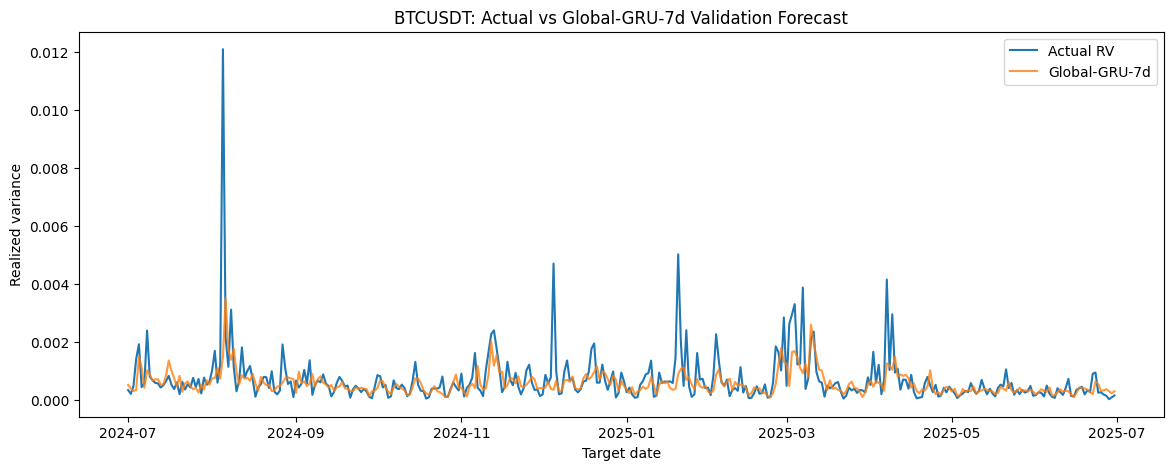

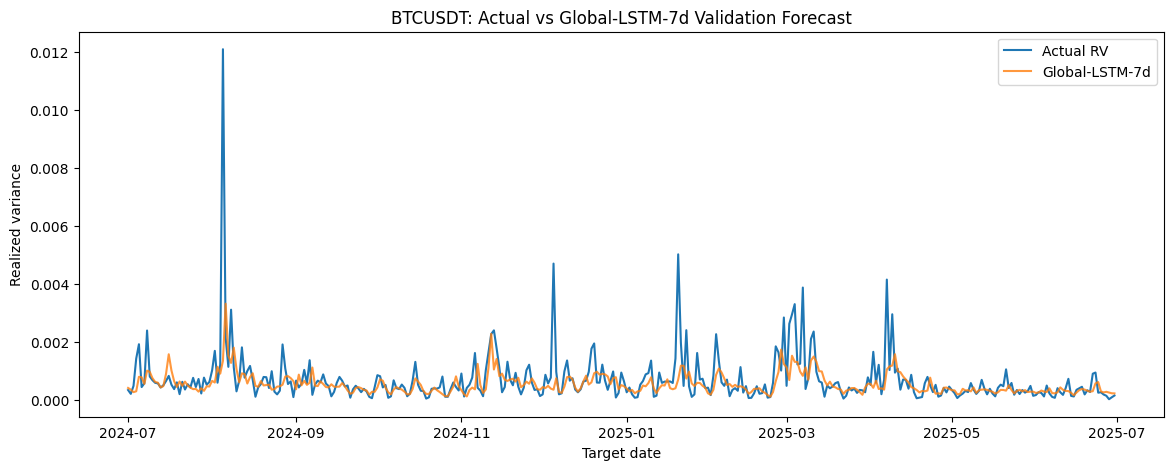

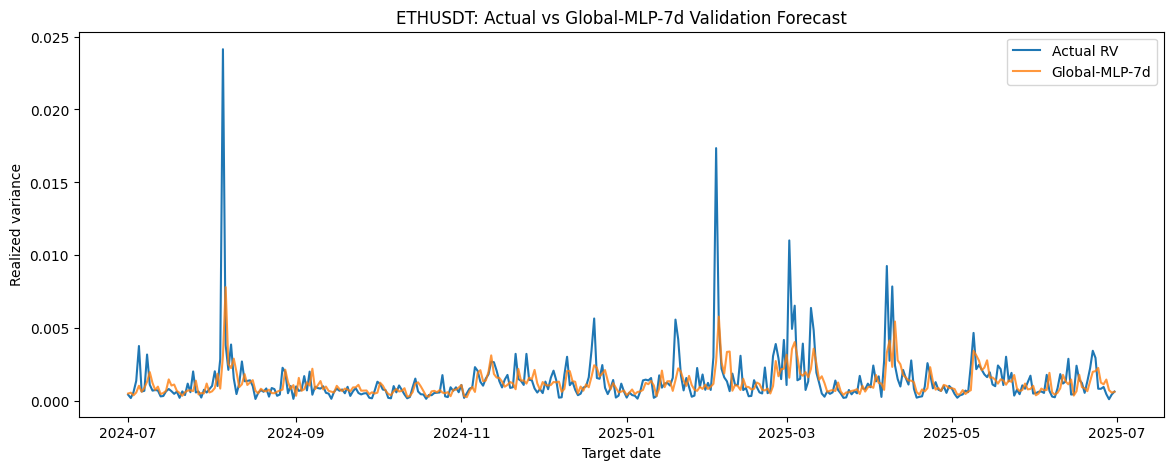

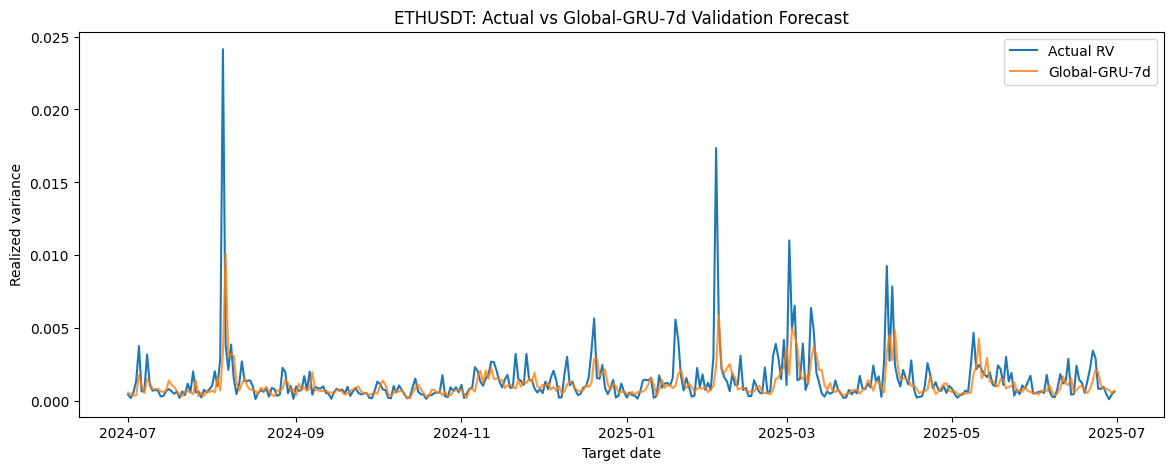

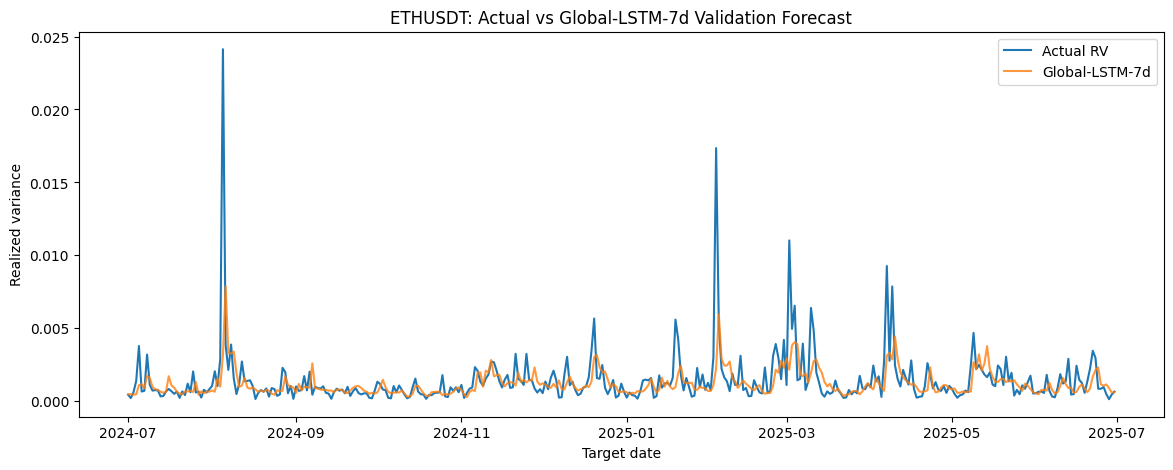

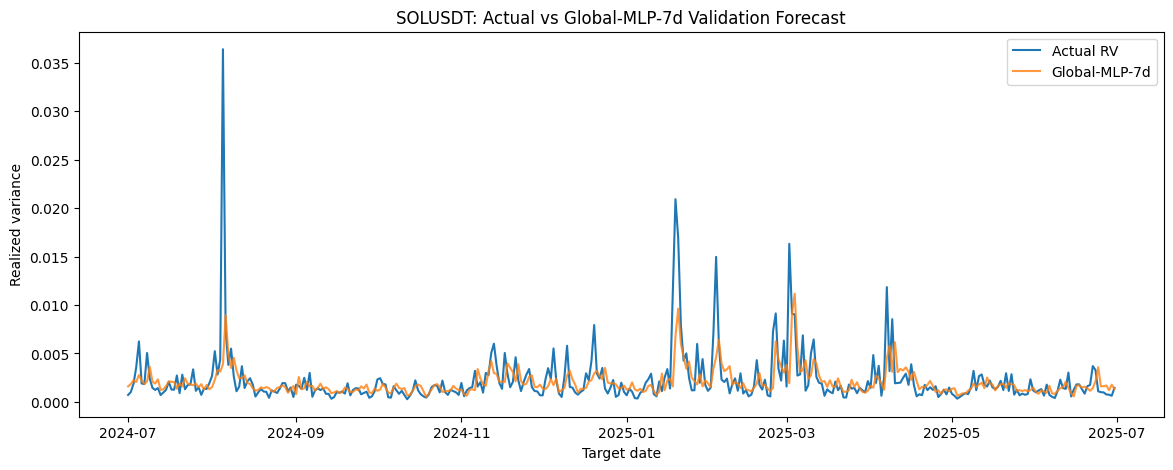

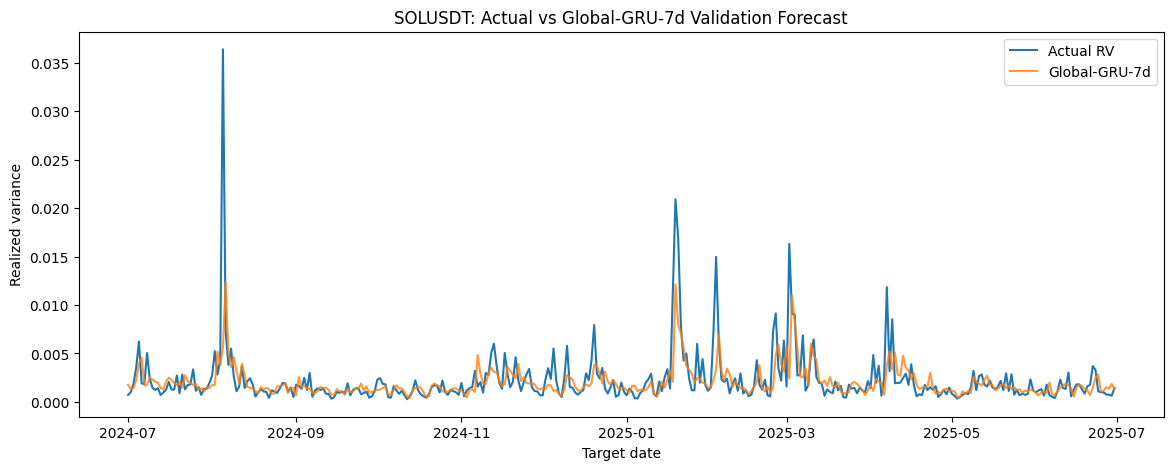

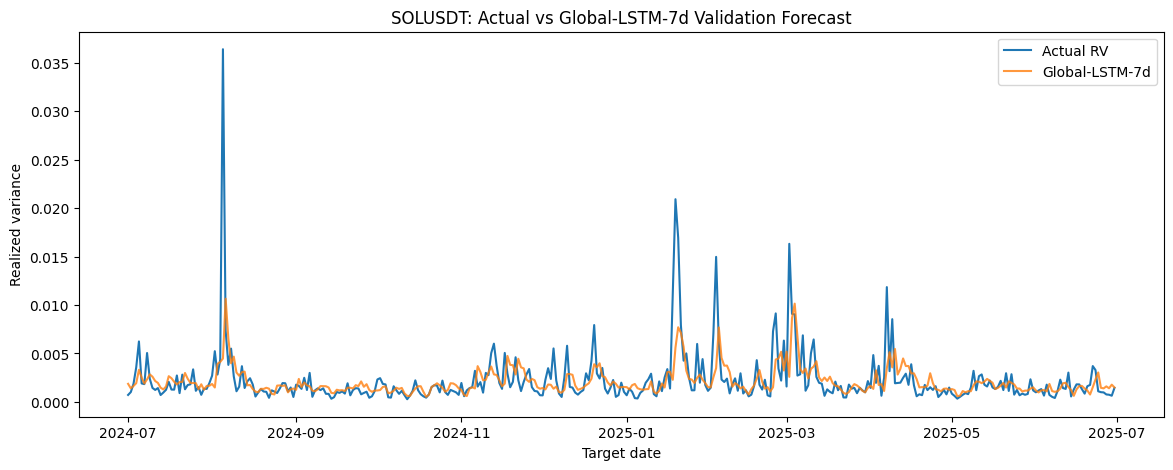

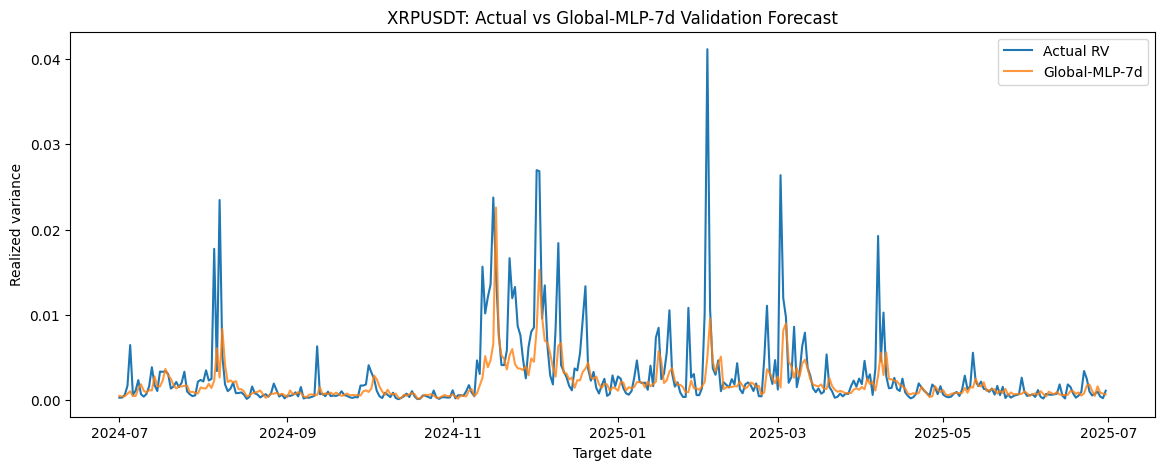

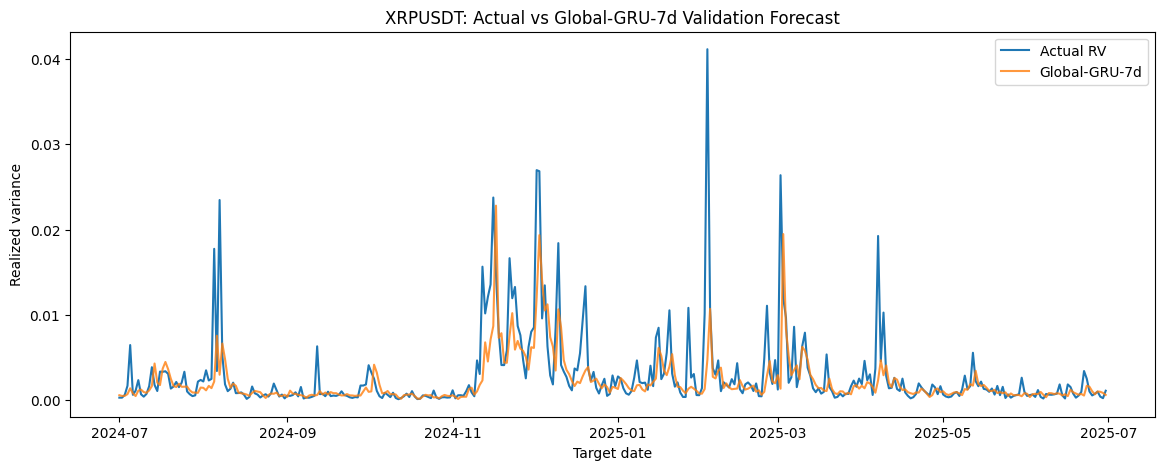

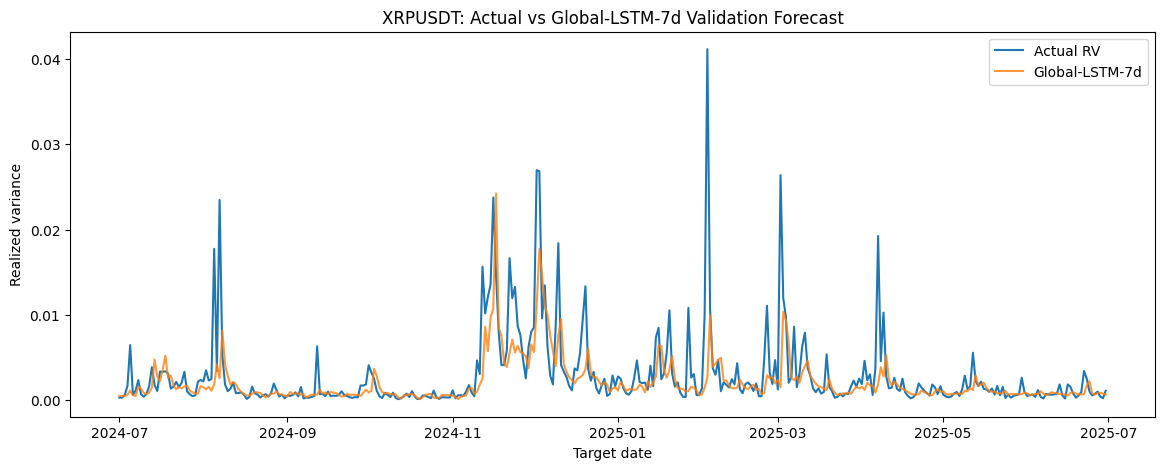

In [15]:
all_predictions_df=pd.concat(prediction_frames,ignore_index=True)
for symbol in ASSETS:
    for model_name in ['Global-MLP-7d','Global-GRU-7d','Global-LSTM-7d']:
        p=all_predictions_df.loc[(all_predictions_df['symbol']==symbol)&(all_predictions_df['model']==model_name)].sort_values('target_date')
        plt.figure(figsize=(14,5))
        plt.plot(p['target_date'],p['actual_rv'],label='Actual RV')
        plt.plot(p['target_date'],p['pred_rv'],label=model_name,alpha=0.8)
        plt.xlabel('Target date'); plt.ylabel('Realized variance'); plt.title(f'{symbol}: Actual vs {model_name} Validation Forecast'); plt.legend(); plt.show()


## Interpretation
Use asset-level validation QLIKE as the primary metric. Keep the test period untouched until the final architecture—including any MLP–GRU fusion model—is frozen.
